## Сверточные нейронные сети (CNN). Компьютерное зрение. Задача классификации изображений

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

### Обучение своей собственной модели
Загрузка датасета для классификации кошек и собак.

In [ ]:
train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/cats_and_dogs", 
    validation_split=0.2, 
    subset="both", 
    seed=81, 
    image_size=(200,400), 
    batch_size=32,
)

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Using 400 files for validation.


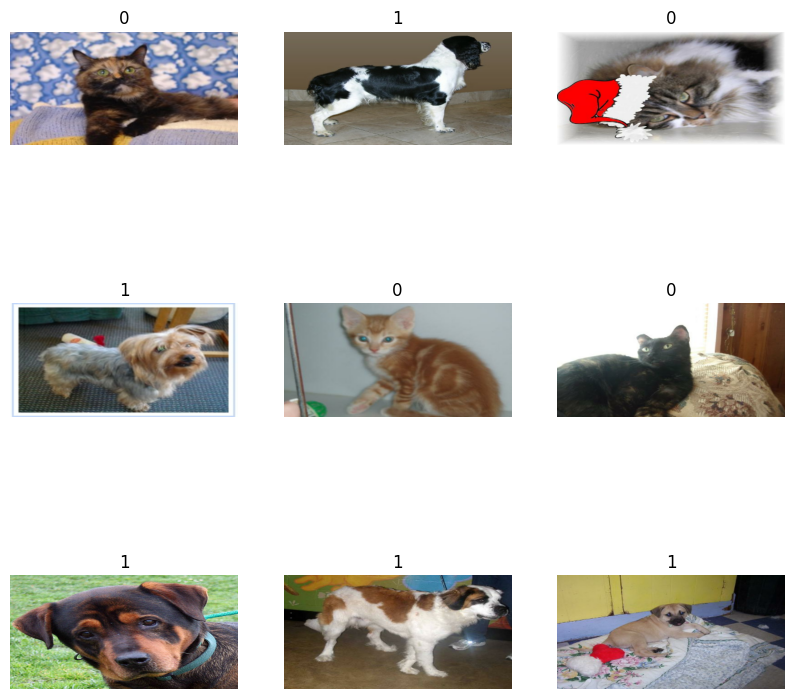

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):   
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

Аугментация

In [9]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomBrightness(0.2)
    ]
)

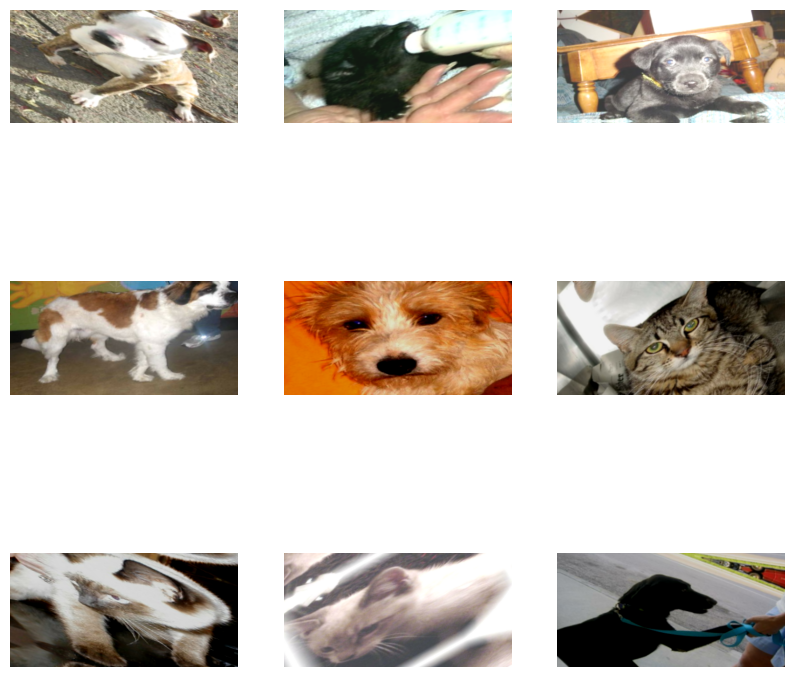

In [10]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

In [ ]:
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label)
)

Сборка CNN с помощью TensorFlow и решение задачи классификации кошек и собак.